In [ ]:
# Module for using Google Drive
from google.colab import drive
drive.mount('/content/drive')



In [ ]:
import sys
sys.path.append('..')
import matplotlib.pyplot as plt
import numpy as np
from common.optimizer import SGD
from dataset import ptb
from ch05.simple_rnnlm import SimpleRnnlm

In [ ]:
# Hyperparameter
batch_size = 10
wordvec_size = 100
hidden_size = 100  # Number of elements in the hidden state vector of RNN
time_size = 5      # Time size unfolded by Truncated BPTT
lr = 0.1
max_epoch = 100


In [ ]:
corpus, word_to_id, id_to_word = ptb.load_data('train')
corpus_size = 1000
corpus = corpus[:corpus_size]
vocab_size = int(max(corpus) + 1)

xs = corpus[:-1]  # Input
ts = corpus[1:]   # Output (target labels)
data_size = len(xs)
print('Corpus size: %d, Vocabulary size: %d' % (corpus_size, vocab_size))


In [ ]:
# Variables used during training
max_iters = data_size // (batch_size * time_size)
time_idx = 0
total_loss = 0
loss_count = 0
ppl_list = []


In [ ]:
# Model creation
model = SimpleRnnlm(vocab_size, wordvec_size, hidden_size)
optimizer = SGD(lr)


In [ ]:
# Calculate the starting position of each sample in the mini-batch
jump = (corpus_size - 1) // batch_size
offsets = [i * jump for i in range(batch_size)]

for epoch in range(max_epoch):
    for iter in range(max_iters):
        # Get mini-batch
        batch_x = np.empty((batch_size, time_size), dtype='i')
        batch_t = np.empty((batch_size, time_size), dtype='i')
        for t in range(time_size):
            for i, offset in enumerate(offsets):
                batch_x[i, t] = xs[(offset + time_idx) % data_size]
                batch_t[i, t] = ts[(offset + time_idx) % data_size]
            time_idx += 1

        # Calculate gradients and update parameters
        loss = model.forward(batch_x, batch_t)
        model.backward()
        optimizer.update(model.params, model.grads)
        total_loss += loss
        loss_count += 1

    # Evaluate perplexity per epoch
    ppl = np.exp(total_loss / loss_count)
    print('| Epoch %d | Perplexity %.2f'
          % (epoch+1, ppl))
    ppl_list.append(float(ppl))
    total_loss, loss_count = 0, 0


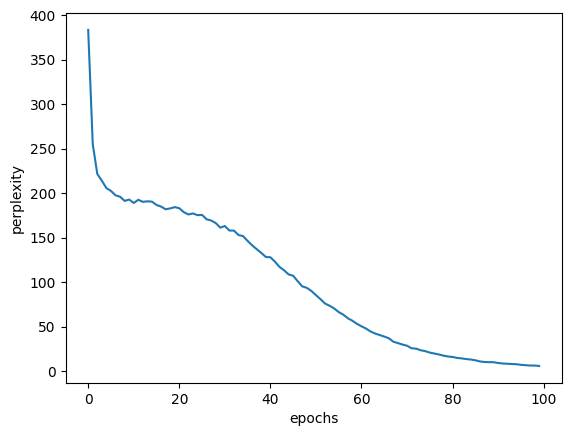

In [ ]:
# 그래프 그리기
x = np.arange(len(ppl_list))
plt.plot(x, ppl_list, label='train')
plt.xlabel('epochs')
plt.ylabel('perplexity')
plt.show()